In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_excel('../data/raw/E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n")
df.info()

Jumlah baris: 5630
Jumlah kolom: 20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


Churn
0    4682
1     948
Name: count, dtype: int64


Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_10312/846415811.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


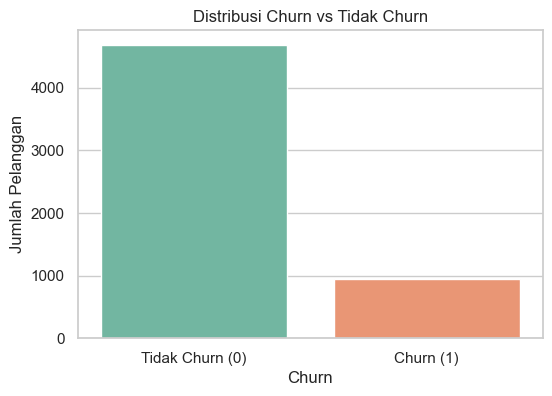

In [7]:
churn_count = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_count)
print("\n")
print(churn_pct.round(2))

# Visualisasi
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Churn vs Tidak Churn')
plt.xticks([0,1], ['Tidak Churn (0)', 'Churn (1)'])
plt.ylabel('Jumlah Pelanggan')
plt.show()

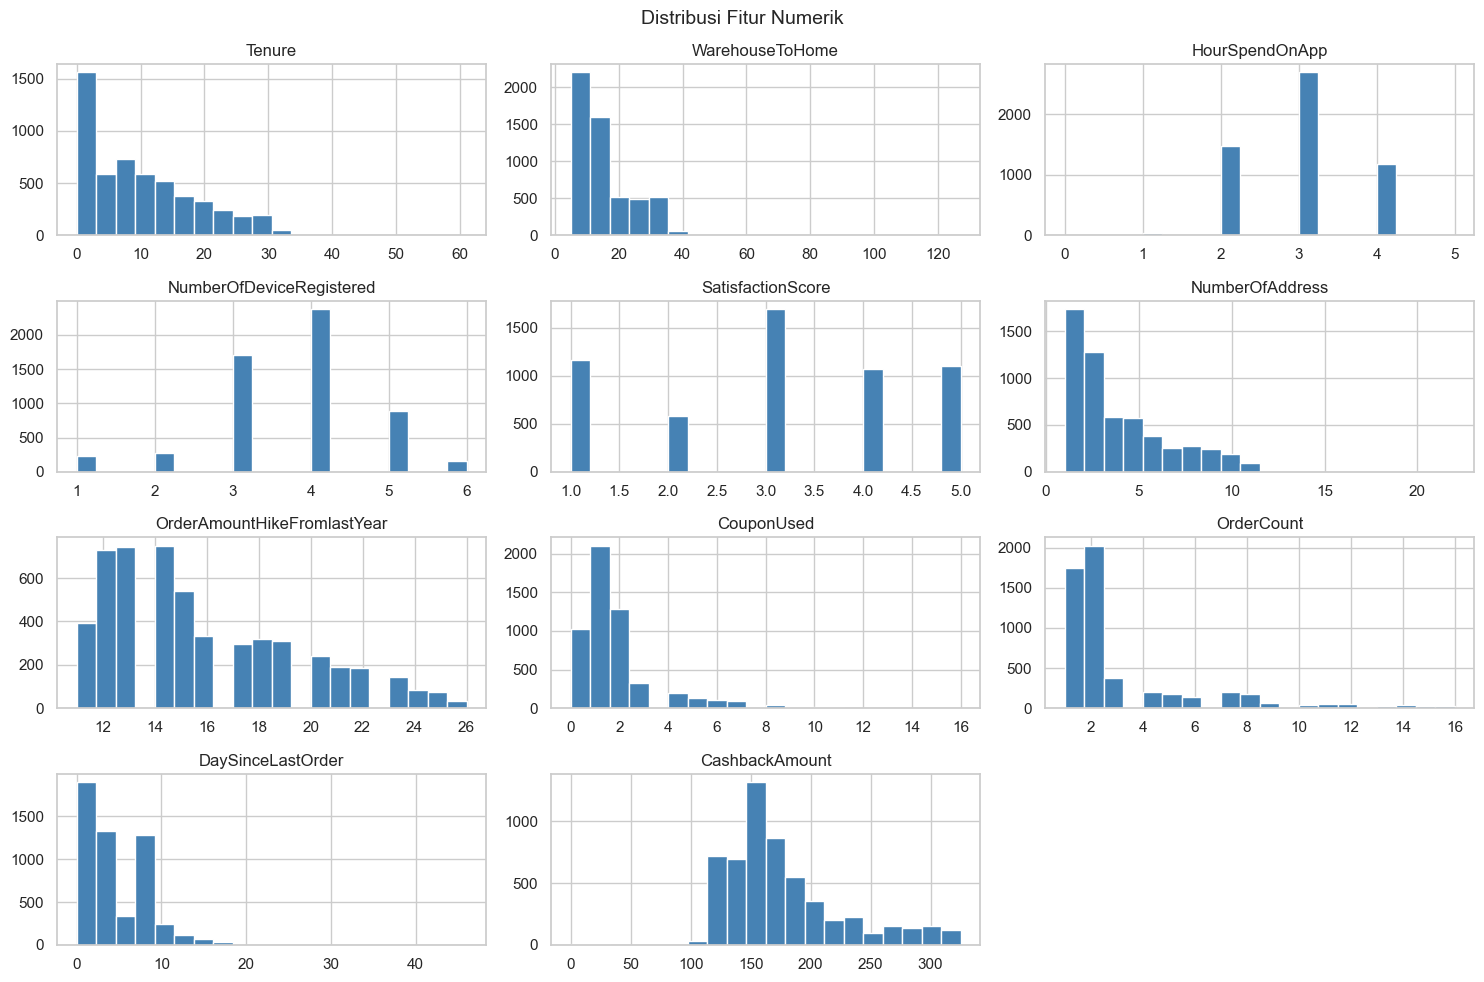

In [8]:
numerical_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
                  'NumberOfDeviceRegistered', 'SatisfactionScore',
                  'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                  'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 
                  'CashbackAmount']

df[numerical_cols].hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

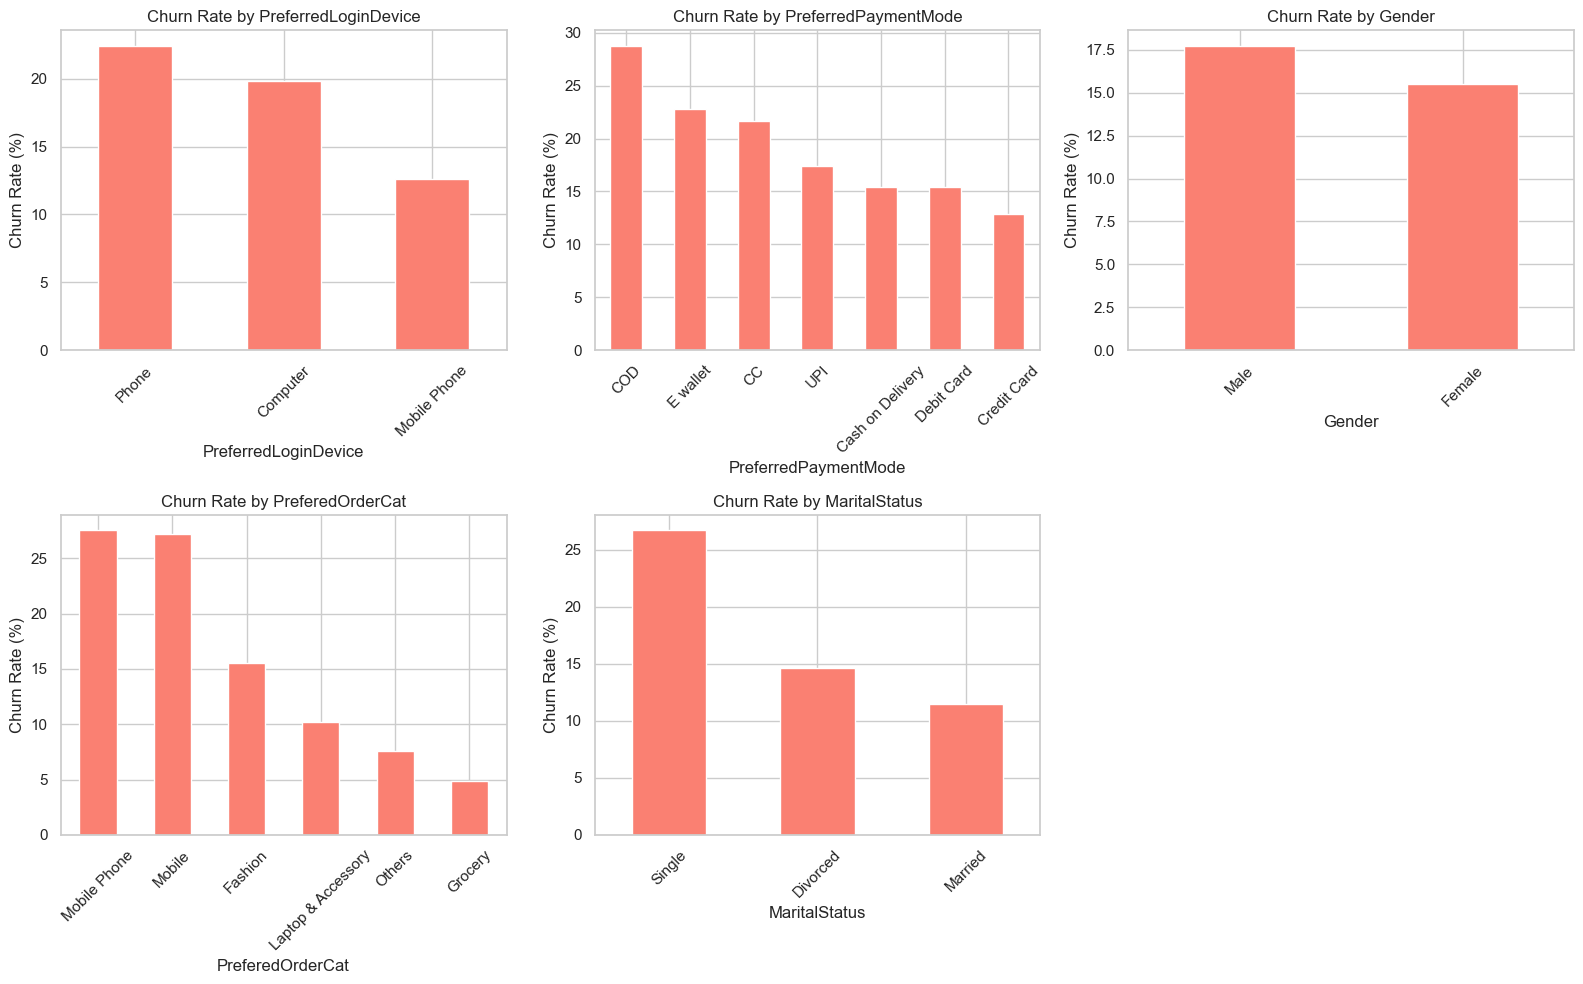

In [9]:
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 
                    'Gender', 'PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='salmon', edgecolor='white'
    )
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

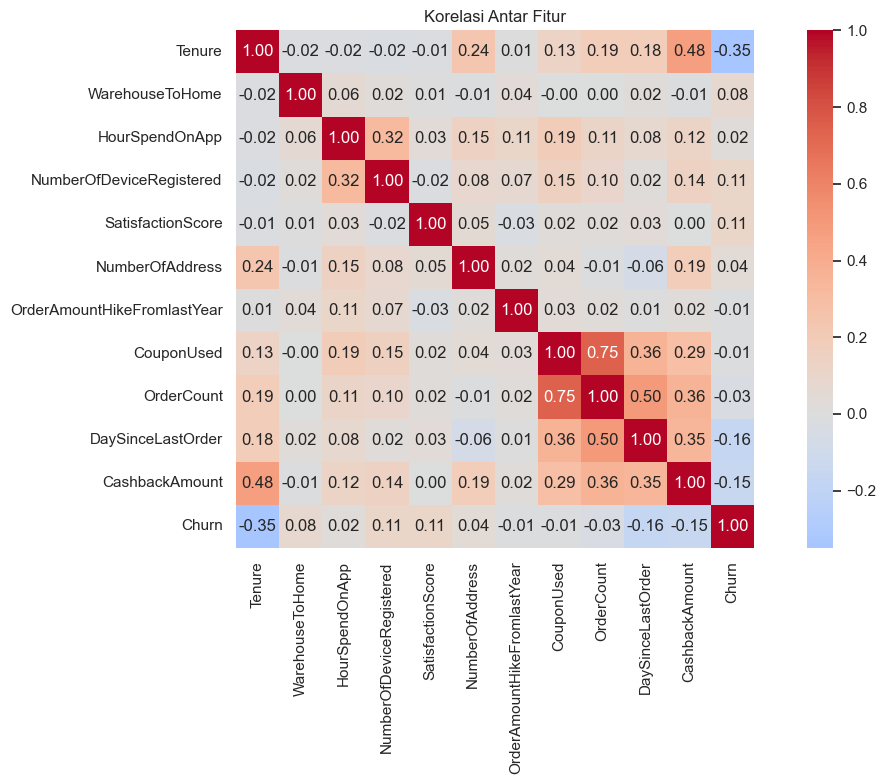

In [10]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

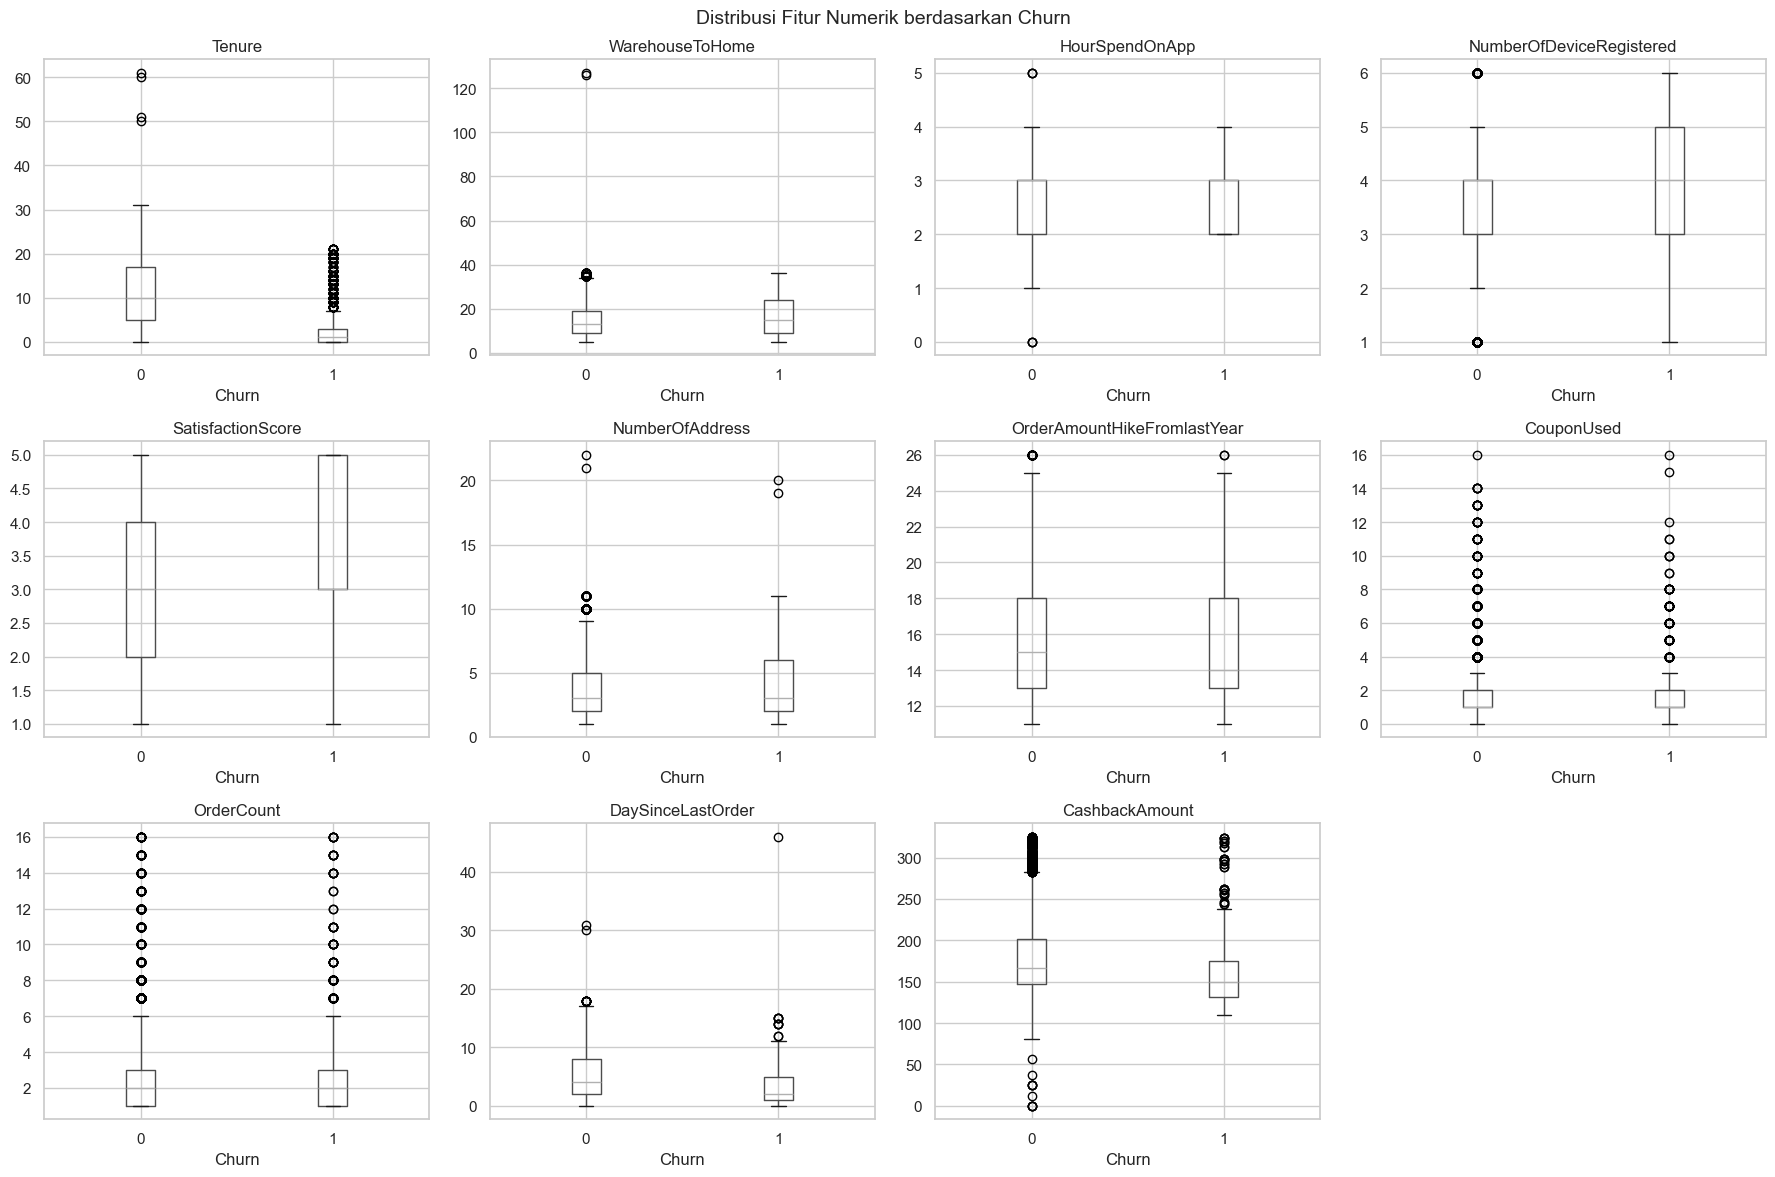

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik berdasarkan Churn', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("SUMMARY EDA — CHURN PREDICTION")
print("=" * 50)

print(f"""
📦 DATASET
- Total pelanggan : {len(df):,}
- Total fitur     : {df.shape[1]}
- Missing values  : 7 kolom (4-5%)

⚖️ CLASS BALANCE
- Tidak Churn (0) : 83.16% ({df[df['Churn']==0].shape[0]:,} pelanggan)
- Churn (1)       : 16.84% ({df[df['Churn']==1].shape[0]:,} pelanggan)
→ IMBALANCED — perlu SMOTE

🔑 FITUR PALING PENTING (dari korelasi)
- Tenure              : -0.35 (makin lama = makin loyal)
- DaySinceLastOrder   : -0.16
- CashbackAmount      : -0.15

📊 INSIGHT KATEGORIK
- COD = payment method dengan churn tertinggi (28%)
- Single = marital status dengan churn tertinggi (26%)
- Phone login = churn lebih tinggi dari Mobile Phone
- Mobile Phone & Mobile category = churn ~27%

⚠️ CATATAN PREPROCESSING
- 7 kolom perlu imputation (median untuk numerik)
- Outlier perlu Winsorization
- Multikolinearity: CouponUsed & OrderCount (0.75)
- Encoding: 5 kolom kategorikal
""")

SUMMARY EDA — CHURN PREDICTION

📦 DATASET
- Total pelanggan : 5,630
- Total fitur     : 20
- Missing values  : 7 kolom (4-5%)

⚖️ CLASS BALANCE
- Tidak Churn (0) : 83.16% (4,682 pelanggan)
- Churn (1)       : 16.84% (948 pelanggan)
→ IMBALANCED — perlu SMOTE

🔑 FITUR PALING PENTING (dari korelasi)
- Tenure              : -0.35 (makin lama = makin loyal)
- DaySinceLastOrder   : -0.16
- CashbackAmount      : -0.15

📊 INSIGHT KATEGORIK
- COD = payment method dengan churn tertinggi (28%)
- Single = marital status dengan churn tertinggi (26%)
- Phone login = churn lebih tinggi dari Mobile Phone
- Mobile Phone & Mobile category = churn ~27%

⚠️ CATATAN PREPROCESSING
- 7 kolom perlu imputation (median untuk numerik)
- Outlier perlu Winsorization
- Multikolinearity: CouponUsed & OrderCount (0.75)
- Encoding: 5 kolom kategorikal

